In [49]:
from langchain.messages import HumanMessage
from langgraph.graph import StateGraph, START, END, MessagesState
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph.message import add_messages, RemoveMessage
from langchain.messages import HumanMessage, AIMessage, SystemMessage

In [23]:
load_dotenv()  # Load environment variables from .env file
llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")

In [24]:
from typing import Annotated
class ChatState(MessagesState):
    summary: Annotated[str, "A summary of the old messages so far."]

In [36]:
from langchain_classic.prompts import MessagesPlaceholder


chat_prompt_template = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are a helpful assistant."
    ),
    MessagesPlaceholder(variable_name="messages"),
    ])

In [37]:
summarize_prompt_template = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are a helpful assistant."
    ),
    MessagesPlaceholder(variable_name="messages"),
    (
        "system",
        "Summarize the conversation so far in pointers. "
        "The summary should be concise and capture the main points of the conversation."
    ),
])

In [38]:
def summarize_conversation(state: ChatState):
    existing_summary = state.get("summary", "")
    messages = state["messages"]
    if existing_summary:
        messages = [{"role": "system", "content": f"Existing summary: {existing_summary}"}] + messages
    
    if len(messages) < 6:
        return {}
    
    summary_chain = summarize_prompt_template | llm
    summary = summary_chain.invoke({"messages": messages})
    
    deleted_messages = state["messages"][:-2]  # Delete all but the last two messages
    
    return {
        "summary": summary.text,
        "messages": [RemoveMessage(id=msg.id) for msg in deleted_messages],  # Keep only the last two messages
    }

In [39]:
def chat_node(state: ChatState):
    messages = []
    existing_summary = state.get("summary", "")
    if existing_summary:
        messages.append({"role": "system", "content": f"Summary of previous messages: {existing_summary}"})
    messages.extend(state["messages"])
    chain = chat_prompt_template | llm
    response = chain.invoke({"messages": messages})
    
    return {"messages": [response]}

In [40]:
def should_summarize(state: ChatState):
    if len(state["messages"]) > 6:
        return 'summarize_conversation'
    else:
        return END

In [41]:
graph = StateGraph(ChatState)
#add nodes
graph.add_node('chat_node', chat_node)
graph.add_node('summarize_conversation', summarize_conversation)

In [42]:
graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', should_summarize)
graph.add_edge('summarize_conversation', END)

In [43]:
from langgraph.checkpoint.memory import MemorySaver

config_t2 = {"configurable" : {"thread_id" :  "deletion_summarization_thread"}}
workflow = graph.compile(checkpointer = MemorySaver())

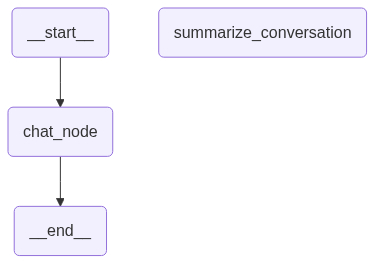

In [44]:
from IPython.display import Image, display
display(Image(workflow.get_graph().draw_mermaid_png()))

In [45]:
response = workflow.invoke({"messages": [{"role": "user", "content": "Hello I am Harshit, explain me about Quantum Computing in detail."}]}, config=config_t2)

In [46]:
print("----SUMMARY----")
print(response.get("summary", "No summary available."))

----SUMMARY----
No summary available.


In [50]:
for msg in response.get("messages", []):
    if isinstance(msg, HumanMessage):
        print(f"User: {msg.text}")
    elif isinstance(msg, AIMessage):
        print(f"AI: {msg.text}")
    elif isinstance(msg, RemoveMessage):
        print(f"Removed message with ID: {msg.id}")
    else:
        print(f"SystemMessage: {msg.text}")
    

User: Hello I am Harshit, explain me about Quantum Computing in detail.
AI: Hello Harshit! It’s great to meet you. Quantum computing is one of the most fascinating and rapidly evolving fields in modern science. 

To understand it in detail, we need to compare it with the classical computers we use today, dive into the mind-bending physics behind it, and look at what it can actually do. Let’s break it down step-by-step.

---

### 1. The Core Concept: Bits vs. Qubits

To understand quantum computers, you first need to understand how regular computers work.

*   **Classical Computers (Bits):** Your laptop, smartphone, and even supercomputers process information using **bits**. A bit is like a light switch—it can only be in one of two positions: **0** or **1**. Every video you watch, game you play, and message you send is ultimately broken down into long strings of 0s and 1s.
*   **Quantum Computers (Qubits):** Quantum computers use **qubits** (quantum bits). Thanks to the laws of quantum 